In [12]:
from matplotlib import pyplot as plt

import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde

#### load the observed and simulated mutation distances

In [3]:
# write the mutation distances for JG0139b to file for the data behind the rainfall plot
sample_distances = {}
sim_sample_distances = {}

sample_distances['JG0139b'] = pd.read_csv('./JG0139b_mut_distances.tsv',sep='\t',index_col=0)
sim_sample_distances['JG0139b'] = pd.read_csv('./simulated_JG0139b_mut_distances.tsv',sep='\t',index_col=0)

sample_distances['JG0139c'] = pd.read_csv('./JG0139c_mut_distances.tsv',sep='\t',index_col=0)
sim_sample_distances['JG0139c'] = pd.read_csv('./simulated_JG0139c_mut_distances.tsv',sep='\t',index_col=0)

sample_distances['JG0139d'] = pd.read_csv('./JG0139d_mut_distances.tsv',sep='\t',index_col=0)
sim_sample_distances['JG0139d'] = pd.read_csv('./simulated_JG0139d_mut_distances.tsv',sep='\t',index_col=0)

sample_distances['JG0139e'] = pd.read_csv('./JG0139e_mut_distances.tsv',sep='\t',index_col=0)
sim_sample_distances['JG0139e'] = pd.read_csv('./simulated_JG0139e_mut_distances.tsv',sep='\t',index_col=0)


#### get chromosome information

In [6]:
genome_dict = './GRCh38.dict'
chrom_lens = []
with open(genome_dict,'r')as f_obj:
    for line in f_obj:
        items = line.split()
        if not items[0] == '@SQ':
            continue
        name = items[1].split(':')[1]
        length = int(items[2].split(':')[1])
        if 'random' in name or 'chrUn' in name or "EBV" in name or 'chrM' in name or 'chrY' in name:
            continue
        name = name[3:]
        chrom_lens.append((name,length))

chrom_names = [i[0] for i in chrom_lens]

chrom_start_size = []
chrom_centers = []
cur_start = 0
for chrom,size in chrom_lens:
    start = cur_start
    end = cur_start+size
    middle = (start+end)/2
    chrom_start_size.append((start,size))
    chrom_centers.append(middle)
    cur_start += size    

#### generate the plot

/tmp/ipykernel_15039/2347857418.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


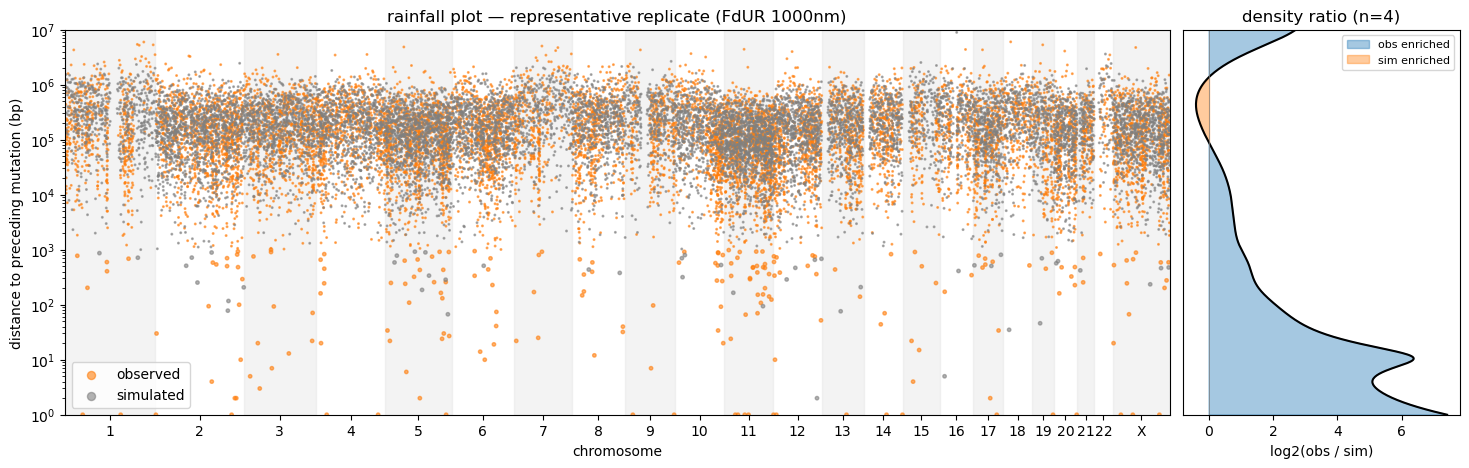

In [15]:
dotsize = 5          # dots above 10**3
dotsize_big = 25     # dots at/below 10**3
size_threshold = 10**3

samples = ['JG0139b', 'JG0139c', 'JG0139d', 'JG0139e']
sname = samples[0]  # rainfall plot uses only the first sample
ylim = (1, 10**7)
xlim = (0, chrom_start_size[-1][0] + chrom_start_size[-1][1])
dotsize = 5
BW = 0.40

fig, (ax, ax_kde) = plt.subplots(
    1, 2, figsize=(18, 5),
    gridspec_kw={'width_ratios': [4, 1], 'wspace': 0.02},
    sharey=True,
)

# --- Rainfall plot (left) — first sample only ---
distances = sample_distances[sname]
sim_distances = sim_sample_distances[sname]

obs_y = np.asarray(distances['dist_to_previous'])
sim_y = np.asarray(sim_distances['dist_to_previous'])
obs_sizes = np.where(obs_y <= size_threshold, dotsize_big, dotsize)
sim_sizes = np.where(sim_y <= size_threshold, dotsize_big, dotsize)

ax.scatter(distances['start_cumulative'], distances['dist_to_previous'],
           marker='.', s=obs_sizes, alpha=0.6, color='C1', label='observed')
ax.scatter(sim_distances['start_cumulative'], sim_distances['dist_to_previous'],
           marker='.', s=sim_sizes, alpha=0.6, color='grey', label='simulated')
ax.set_yscale('log')
ax.set_ylim(*ylim)
ax.set_xlim(*xlim)
ax.set_title(f'rainfall plot — representative replicate (FdUR 1000nm)')
ax.set_ylabel('distance to preceding mutation (bp)')
ax.set_xlabel('chromosome')
ax.legend(markerscale=3)

# --- Density ratio side panel — pooled across all 4 samples ---
obs_vals = np.concatenate([
    np.asarray(sample_distances[s]['dist_to_previous']) for s in samples
])
sim_vals = np.concatenate([
    np.asarray(sim_sample_distances[s]['dist_to_previous']) for s in samples
])

obs_vals = obs_vals[(obs_vals >= ylim[0]) & (obs_vals <= ylim[1])]
sim_vals = sim_vals[(sim_vals >= ylim[0]) & (sim_vals <= ylim[1])]

y_grid = np.logspace(np.log10(ylim[0]), np.log10(ylim[1]), 500)
log_y_grid = np.log10(y_grid)

kde_obs = gaussian_kde(np.log10(obs_vals), bw_method=BW)(log_y_grid)
kde_sim = gaussian_kde(np.log10(sim_vals), bw_method=BW)(log_y_grid)

eps = 1e-9
ratio = np.log2((kde_obs + eps) / (kde_sim + eps))

threshold = 1e-3 * max(kde_obs.max(), kde_sim.max())
mask = (kde_obs < threshold) & (kde_sim < threshold)
ratio_masked = np.where(mask, np.nan, ratio)

ax_kde.plot(ratio_masked, y_grid, color='k', lw=1.5)
ax_kde.fill_betweenx(y_grid, 0, ratio_masked, where=(ratio_masked > 0),
                     color='C0', alpha=0.4, label='obs enriched')
ax_kde.fill_betweenx(y_grid, 0, ratio_masked, where=(ratio_masked < 0),
                     color='C1', alpha=0.4, label='sim enriched')
ax_kde.axvline(0, color='gray', lw=0.5)

ax_kde.set_xlabel('log2(obs / sim)')
ax_kde.tick_params(axis='y', which='both', left=False)
ax_kde.set_title(f'density ratio (n={len(samples)})')
ax_kde.legend(fontsize=8, loc='upper right')


# draw the chromosome boxes
for k,(start,size) in enumerate(chrom_start_size):
    if (k+1)%2 == 0:
        continue
    ax.add_patch(plt.Rectangle((start,ylim[0]),
                    width = size,height = ylim[1]-ylim[0],
                    color='lightgrey',alpha=0.25,zorder=0),
                   )
ax.set_xticks(chrom_centers)
ax.set_xticklabels(chrom_names)



plt.tight_layout()

plt.show()